# Phase 1C — Synthetic Distribution

Generate plausible radial distribution networks (13.8 kV) for every Visayas province. OSM has effectively no distribution data (Phase 1A: 0 provinces `osm_good`), so this notebook produces the bulk of the distribution layer from scratch.

**Approach** (per plan v2 §1C.2):
- For each transmission substation, generate `n_feeders=4` radial feeders
- Each feeder is a chain of `branches_per_feeder=6` distribution buses placed within the province polygon
- Provinces with no transmission substations get a synthetic root at the province centroid (will be isolated until v1 CSV data fills the transmission gap)
- Each synthetic bus gets a 1.5 MW peak load (PF 0.9 → 0.73 MVAr Q)
- All synthesised rows: `is_synthetic=True`, `data_source='synthetic'`

**Outputs:** appended rows in [buses.csv](../backend/data/processed/buses.csv) and [lines.csv](../backend/data/processed/lines.csv) — transmission rows preserved, distribution rows added.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import math

PROC_DIR = Path('../backend/data/processed')
BOUND_DIR = Path('../backend/data/boundaries')

WGS = 'EPSG:4326'
UTM = 'EPSG:32651'

DIST_VOLTAGE_KV     = 13.8
N_FEEDERS_PER_ROOT  = 4
BRANCHES_PER_FEEDER = 6
LOAD_PER_BUS_MW     = 1.5         # peak P per distribution bus
PF                  = 0.9         # assumed power factor
TAN_PHI             = math.tan(math.acos(PF))  # ≈ 0.484

# 13.8 kV ACSR overhead distribution typical values
DIST_R_OHM_PER_KM = 0.10
DIST_X_OHM_PER_KM = 0.15
DIST_MAX_I_KA     = 0.30

# Feeder geometry
FEEDER_MIN_KM    = 5.0   # closest branch bus to root
FEEDER_MAX_KM    = 25.0  # farthest branch bus from root
MAX_REJECT_TRIES = 200

RNG = np.random.default_rng(seed=20260511)  # deterministic synthesis
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
audit     = pd.read_csv(PROC_DIR / 'coverage_audit.csv', dtype={'psgc_code': str})
buses_tx  = pd.read_csv(PROC_DIR / 'buses.csv')
lines_tx  = pd.read_csv(PROC_DIR / 'lines.csv')
provinces = gpd.read_file(BOUND_DIR / 'psgc_provinces.geojson')

print(f'Transmission inputs: {len(buses_tx)} buses, {len(lines_tx)} lines')
print(f'Provinces: {len(provinces)}')
print(f'Phase 1C class distribution: {audit["phase1c_class"].value_counts().to_dict()}')

Transmission inputs: 186 buses, 194 lines
Provinces: 16
Phase 1C class distribution: {'osm_empty': 12, 'osm_partial': 4}


## §1 — Per-province root assignment

Each province needs at least one root (substation) to anchor distribution feeders. If OSM has no transmission substations in a province, synthesise a virtual root at the province centroid and flag it. The virtual root will be isolated from the rest of the grid until Phase 1B is augmented with v1 CSV data.

In [3]:
real_subs = buses_tx[buses_tx['bus_type'] == 'substation'].copy()
print(f'Real transmission substations available as roots: {len(real_subs)}')

subs_per_province = real_subs.groupby('province').size()
needs_virtual = sorted(set(provinces['province']) - set(subs_per_province.index))
print(f'Provinces with NO transmission substation (need virtual root): {needs_virtual}')

Real transmission substations available as roots: 101
Provinces with NO transmission substation (need virtual root): ['Aklan', 'Antique', 'Capiz', 'Guimaras']


In [4]:
# Build virtual roots for provinces lacking transmission substations
virtual_root_rows = []
prov_m = provinces.to_crs(UTM)
for prov_name in needs_virtual:
    prow = prov_m[prov_m['province'] == prov_name].iloc[0]
    centroid_m = prow.geometry.representative_point()
    # Project centroid back to WGS for the bus row
    centroid_wgs = gpd.GeoSeries([centroid_m], crs=UTM).to_crs(WGS).iloc[0]
    bus_id = f'sub_synth_{prov_name.lower().replace(" ", "_")}'
    virtual_root_rows.append({
        'bus_id': bus_id,
        'name': f'Synthetic root — {prov_name}',
        'lat': centroid_wgs.y,
        'lon': centroid_wgs.x,
        'voltage_kv': 138.0,  # placeholder transmission voltage
        'province': prov_name,
        'island': prow['island_name'],
        'bus_type': 'substation_synth',
        'p_mw': np.nan,
        'q_mvar': np.nan,
        'is_synthetic': True,
        'data_source': 'synthetic',
    })
virtual_roots_df = pd.DataFrame(virtual_root_rows)
print(f'Created {len(virtual_roots_df)} virtual roots:')
print(virtual_roots_df[['bus_id', 'province', 'island', 'lat', 'lon']].to_string(index=False))

Created 4 virtual roots:
            bus_id province   island       lat        lon
   sub_synth_aklan    Aklan    Panay 11.626336 122.226799
 sub_synth_antique  Antique    Panay 11.117408 122.145652
   sub_synth_capiz    Capiz    Panay 11.376455 122.645114
sub_synth_guimaras Guimaras Guimaras 10.579733 122.608315


In [5]:
# Combined root list (real substations + virtual roots)
all_roots = pd.concat([real_subs, virtual_roots_df], ignore_index=True, sort=False)
print(f'Total root buses available for distribution: {len(all_roots)}')
print(f'Per-province root count:')
print(all_roots.groupby('province').size().to_string())

Total root buses available for distribution: 105
Per-province root count:
province
Aklan                 1
Antique               1
Biliran               1
Bohol                 9
Capiz                 1
Cebu                 38
Eastern Samar         2
Guimaras              1
Iloilo                1
Leyte                17
Negros Occidental    10
Negros Oriental       9
Northern Samar        3
Samar                 7
Siquijor              1
Southern Leyte        3


## §2 — Radial feeder generator

For one root, generate `N_FEEDERS_PER_ROOT` feeders. Each feeder is a chain of `BRANCHES_PER_FEEDER` distribution buses extending outward from the root. Branch points are placed within the province polygon at increasing distance, with directional fan-out so feeders don't overlap.

In [6]:
def random_point_in_polygon(poly, around_point_m, min_dist_m, max_dist_m, bearing_rad, rng):
    """Sample a point inside `poly` at distance ∈ [min_dist, max_dist] from
    `around_point_m`, in a wedge centered on `bearing_rad`. Returns shapely.Point in UTM."""
    wedge_half_width = math.radians(35)  # ±35° from bearing
    for _ in range(MAX_REJECT_TRIES):
        d = rng.uniform(min_dist_m, max_dist_m)
        theta = rng.uniform(bearing_rad - wedge_half_width, bearing_rad + wedge_half_width)
        x = around_point_m.x + d * math.cos(theta)
        y = around_point_m.y + d * math.sin(theta)
        p = Point(x, y)
        if poly.contains(p):
            return p
    return None  # caller decides what to do

def synthesize_feeders_for_root(root_row, province_poly_m, n_feeders, branches, rng):
    """Returns (bus_rows, line_rows) for one root's feeders. All geometry in UTM."""
    # Project root to UTM
    root_pt_m = gpd.GeoSeries(
        [Point(root_row['lon'], root_row['lat'])], crs=WGS
    ).to_crs(UTM).iloc[0]

    bus_rows = []
    line_rows = []
    bearings = np.linspace(0, 2 * math.pi, n_feeders, endpoint=False)
    bearings += rng.uniform(0, 2 * math.pi / n_feeders)  # random phase offset

    for f_idx, bearing in enumerate(bearings):
        prev_bus_id = root_row['bus_id']
        prev_pt = root_pt_m
        for b_idx in range(branches):
            min_d = FEEDER_MIN_KM * 1000 * (b_idx + 1) / branches
            max_d = FEEDER_MAX_KM * 1000 * (b_idx + 1) / branches
            pt = random_point_in_polygon(
                province_poly_m, root_pt_m, min_d, max_d, bearing, rng)
            if pt is None:
                # Couldn't place — stop this feeder early
                break
            new_bus_id = f'{root_row["bus_id"]}_F{f_idx}_B{b_idx}'
            bus_rows.append({
                '_pt_m': pt,
                'bus_id': new_bus_id,
                'name': new_bus_id,
                'voltage_kv': DIST_VOLTAGE_KV,
                'province': root_row['province'],
                'island': root_row['island'],
                'bus_type': 'distribution',
                'p_mw': LOAD_PER_BUS_MW,
                'q_mvar': LOAD_PER_BUS_MW * TAN_PHI,
                'is_synthetic': True,
                'data_source': 'synthetic',
            })
            length_m = prev_pt.distance(pt)
            line_rows.append({
                '_geom_m_start': prev_pt,
                '_geom_m_end': pt,
                'from_bus': prev_bus_id,
                'to_bus': new_bus_id,
                'voltage_kv': DIST_VOLTAGE_KV,
                'length_km': length_m / 1000,
                'r_ohm_per_km': DIST_R_OHM_PER_KM,
                'x_ohm_per_km': DIST_X_OHM_PER_KM,
                'max_i_ka': DIST_MAX_I_KA,
                'is_submarine': False,
                'cable_type': 'overhead',
                'is_synthetic': True,
                'data_source': 'synthetic',
            })
            prev_bus_id = new_bus_id
            prev_pt = pt
    return bus_rows, line_rows

## §3 — Run synthesis for every root in every province

Loop provinces → roots → feeders. All roots in a given province sample from the same UTM-projected province polygon to keep distribution buses inside province boundaries.

In [7]:
all_bus_rows = []
all_line_rows = []
synth_summary = []

for prov_name in sorted(provinces['province']):
    prov_poly_m = prov_m[prov_m['province'] == prov_name].iloc[0].geometry
    roots_here = all_roots[all_roots['province'] == prov_name]
    prov_buses_added = 0
    prov_lines_added = 0
    for _, root in roots_here.iterrows():
        b_rows, l_rows = synthesize_feeders_for_root(
            root, prov_poly_m, N_FEEDERS_PER_ROOT, BRANCHES_PER_FEEDER, RNG)
        all_bus_rows.extend(b_rows)
        all_line_rows.extend(l_rows)
        prov_buses_added += len(b_rows)
        prov_lines_added += len(l_rows)
    synth_summary.append({
        'province': prov_name,
        'roots': len(roots_here),
        'synth_buses': prov_buses_added,
        'synth_lines': prov_lines_added,
        'synth_load_mw': prov_buses_added * LOAD_PER_BUS_MW,
    })

summary_df = pd.DataFrame(synth_summary)
print(f'Total synthesised buses: {len(all_bus_rows)}')
print(f'Total synthesised lines: {len(all_line_rows)}')
print(f'Total synthesised peak load: {len(all_bus_rows) * LOAD_PER_BUS_MW:.0f} MW')
print()
print(summary_df.to_string(index=False))

Total synthesised buses: 2232
Total synthesised lines: 2232
Total synthesised peak load: 3348 MW

         province  roots  synth_buses  synth_lines  synth_load_mw
            Aklan      1           24           24           36.0
          Antique      1           24           24           36.0
          Biliran      1           18           18           27.0
            Bohol      9          186          186          279.0
            Capiz      1           24           24           36.0
             Cebu     38          812          812         1218.0
    Eastern Samar      2           48           48           72.0
         Guimaras      1           24           24           36.0
           Iloilo      1           24           24           36.0
            Leyte     17          364          364          546.0
Negros Occidental     10          226          226          339.0
  Negros Oriental      9          172          172          258.0
   Northern Samar      3           66       

## §4 — Convert synth rows to WGS lat/lon and assemble final DataFrames

In [8]:
# Project synth bus points back to WGS
synth_buses_m = gpd.GeoDataFrame(
    all_bus_rows,
    geometry=[r['_pt_m'] for r in all_bus_rows], crs=UTM,
).to_crs(WGS)
synth_buses_df = pd.DataFrame({
    'bus_id': synth_buses_m['bus_id'],
    'name':   synth_buses_m['name'],
    'lat':    synth_buses_m.geometry.y,
    'lon':    synth_buses_m.geometry.x,
    'voltage_kv': synth_buses_m['voltage_kv'],
    'province':   synth_buses_m['province'],
    'island':     synth_buses_m['island'],
    'bus_type':   synth_buses_m['bus_type'],
    'p_mw':       synth_buses_m['p_mw'],
    'q_mvar':     synth_buses_m['q_mvar'],
    'is_synthetic': synth_buses_m['is_synthetic'],
    'data_source':  synth_buses_m['data_source'],
})

# Line IDs assigned after concatenation
synth_lines_df = pd.DataFrame(all_line_rows).drop(columns=['_geom_m_start', '_geom_m_end'])
synth_lines_df['line_id'] = [f'line_synth_{i:05d}' for i in range(len(synth_lines_df))]
synth_lines_df = synth_lines_df[[
    'line_id', 'from_bus', 'to_bus', 'voltage_kv', 'length_km',
    'r_ohm_per_km', 'x_ohm_per_km', 'max_i_ka',
    'is_submarine', 'cable_type', 'is_synthetic', 'data_source',
]]

print(f'Synth buses ready: {len(synth_buses_df)}')
print(f'Synth lines ready: {len(synth_lines_df)}')

Synth buses ready: 2232
Synth lines ready: 2232


## §5 — Merge with transmission, validate, save

In [9]:
# Add the 4 virtual roots to buses (they were synthesised but not yet in any CSV)
buses_combined = pd.concat([buses_tx, virtual_roots_df, synth_buses_df],
                            ignore_index=True)
lines_combined = pd.concat([lines_tx, synth_lines_df], ignore_index=True)

print(f'Combined buses: {len(buses_combined)} '
      f'(tx={len(buses_tx)}, virtual_roots={len(virtual_roots_df)}, dist={len(synth_buses_df)})')
print(f'Combined lines: {len(lines_combined)} '
      f'(tx={len(lines_tx)}, dist={len(synth_lines_df)})')

# Schema checks
assert buses_combined['bus_id'].is_unique, 'Duplicate bus_id!'
assert lines_combined['line_id'].is_unique, 'Duplicate line_id!'
valid_buses = set(buses_combined['bus_id'])
missing_from = ~lines_combined['from_bus'].isin(valid_buses)
missing_to   = ~lines_combined['to_bus'].isin(valid_buses)
assert not missing_from.any(), f'{missing_from.sum()} lines reference missing from_bus'
assert not missing_to.any(),   f'{missing_to.sum()} lines reference missing to_bus'
assert buses_combined['province'].notna().all(), 'Buses missing province'
print('All schema checks passed ✓')

Combined buses: 2422 (tx=186, virtual_roots=4, dist=2232)
Combined lines: 2426 (tx=194, dist=2232)
All schema checks passed ✓


In [10]:
# Distribution buses per province
by_class = buses_combined.groupby(['province', 'bus_type']).size().unstack(fill_value=0)
print('Bus count by province and type:')
print(by_class.to_string())

# Load totals
load_by_province = buses_combined.groupby('province')['p_mw'].sum()
print(f'\nTotal synthetic peak load by province (MW):')
print(load_by_province.sort_values(ascending=False).round(1).to_string())
print(f'\nTotal Visayas synthetic peak load: {load_by_province.sum():.0f} MW')

Bus count by province and type:
bus_type           distribution  substation  substation_synth  tower
province                                                            
Aklan                        24           0                 1      0
Antique                      24           0                 1      0
Biliran                      18           1                 0      0
Bohol                       186           9                 0      5
Capiz                        24           0                 1      0
Cebu                        812          38                 0     16
Eastern Samar                48           2                 0     15
Guimaras                     24           0                 1      0
Iloilo                       24           1                 0      1
Leyte                       364          17                 0     20
Negros Occidental           226          10                 0     13
Negros Oriental             172           9                 0      6
No

In [11]:
# Connectivity (informational — distribution adds tree structure; transmission still fragmented)
import networkx as nx
G = nx.Graph()
G.add_nodes_from(buses_combined['bus_id'])
G.add_edges_from(zip(lines_combined['from_bus'], lines_combined['to_bus']))
ncc = nx.number_connected_components(G)
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f'Combined graph: {ncc} components, sizes (top 5): {sizes[:5]}, isolated: {sizes.count(1)}')

Combined graph: 71 components, sizes (top 5): [890, 203, 28, 26, 26], isolated: 1


Text(103.84722222222221, 0.5, 'Latitude')

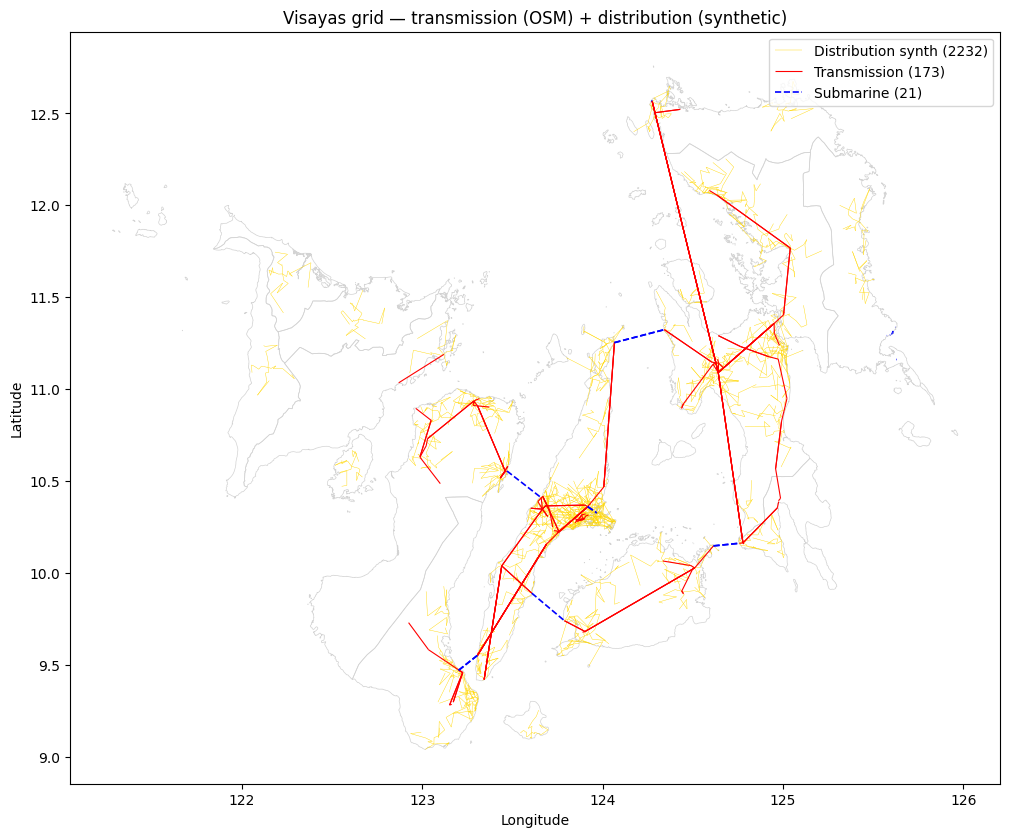

In [12]:
# Visual smoke test
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
provinces.boundary.plot(ax=ax, color='lightgrey', linewidth=0.5)

# Distribution lines (synth)
dist_lines = lines_combined[lines_combined['is_synthetic'] & ~lines_combined['is_submarine']]
# Need geometry — recompute from from_bus/to_bus coordinates
bus_lookup = buses_combined.set_index('bus_id')[['lat', 'lon']]
from shapely.geometry import LineString
def to_geom(row):
    a = bus_lookup.loc[row['from_bus']]
    b = bus_lookup.loc[row['to_bus']]
    return LineString([(a['lon'], a['lat']), (b['lon'], b['lat'])])
dist_gdf = gpd.GeoDataFrame(dist_lines.copy(),
                             geometry=dist_lines.apply(to_geom, axis=1), crs=WGS)
tx_lines_overhead = lines_combined[~lines_combined['is_synthetic'] & ~lines_combined['is_submarine']]
tx_gdf = gpd.GeoDataFrame(tx_lines_overhead.copy(),
                           geometry=tx_lines_overhead.apply(to_geom, axis=1), crs=WGS)
sub_lines = lines_combined[lines_combined['is_submarine']]
sub_gdf = gpd.GeoDataFrame(sub_lines.copy(),
                            geometry=sub_lines.apply(to_geom, axis=1), crs=WGS)

if len(dist_gdf):
    dist_gdf.plot(ax=ax, color='gold', linewidth=0.3, label=f'Distribution synth ({len(dist_gdf)})')
if len(tx_gdf):
    tx_gdf.plot(ax=ax, color='red', linewidth=0.8, label=f'Transmission ({len(tx_gdf)})')
if len(sub_gdf):
    sub_gdf.plot(ax=ax, color='blue', linewidth=1.2, linestyle='--', label=f'Submarine ({len(sub_gdf)})')
ax.legend(loc='upper right')
ax.set_title('Visayas grid — transmission (OSM) + distribution (synthetic)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

In [13]:
# Save
buses_combined.to_csv(PROC_DIR / 'buses.csv', index=False)
lines_combined.to_csv(PROC_DIR / 'lines.csv', index=False)
summary_df.to_csv(PROC_DIR / 'synth_distribution_summary.csv', index=False)
print(f'Wrote {PROC_DIR / "buses.csv"} ({len(buses_combined)} rows)')
print(f'Wrote {PROC_DIR / "lines.csv"} ({len(lines_combined)} rows)')
print(f'Wrote {PROC_DIR / "synth_distribution_summary.csv"} ({len(summary_df)} rows)')

Wrote ../backend/data/processed/buses.csv (2422 rows)
Wrote ../backend/data/processed/lines.csv (2426 rows)
Wrote ../backend/data/processed/synth_distribution_summary.csv (16 rows)
